# Fine-tuning a masked language model


In many NLP applications, if you want to use a Transformer model, you can take a pretrained model from the Hugging Face Hub and directly fine-tune it on your own task-specific data. If the corpus used for pretraining and the corpus used for fine-tuning are not very different, transfer learning usually gives good results. However, in some cases, before training a task-specific head, you first need to fine-tune the language model on your own data. For example, if your dataset contains legal contracts or scientific articles, then a general Transformer model like BERT may treat the domain-specific words in your corpus as rare tokens. As a result, the performance may not be very good. To reduce this problem, if you first fine-tune the language model on your own domain-specific data, the performance on downstream tasks can improve a lot. The good thing is that usually you only need to do this once. This process of fine-tuning a pretrained language model on your own domain data is usually called domain adaptation. It became popular in 2018 through ULMFiT. ULMFiT was one of the first neural architectures in NLP to make transfer learning work effectively, and it was based on LSTMs. In this section, we will do something similar, but instead of using an LSTM, we will use a Transformer. By the end of this section, you will have a masked language model on the Hugging Face Hub that can autocomplete sentences.



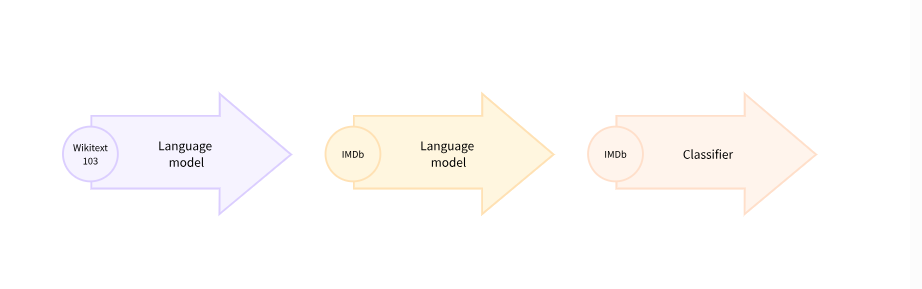

# 1. Picking a pretrained model for masked language modeling

To begin, we need to choose a pretrained model that is suitable for masked language modeling. On the Hugging Face Hub, if you apply the “Fill-Mask” filter, you can see a list of such models. Although the BERT and RoBERTa families are the most downloaded, here we will use DistilBERT, because it can be trained much faster and usually gives little to no loss in downstream performance. This model was trained using a technique called knowledge distillation. In this method, a large “teacher model” like BERT is used to guide the training of a smaller “student model.” As a result, the student model has fewer parameters, but still keeps much of the performance. Now let’s download DistilBERT using the AutoModelForMaskedLM class:

In [1]:
from transformers import AutoModelForMaskedLM

model_checkpoint = "distilbert-base-uncased"
model = AutoModelForMaskedLM.from_pretrained(model_checkpoint)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Now we can check how many parameters the model has using the num_parameters() method:


In [2]:
distilbert_num_parameters = model.num_parameters()/1_000_000

In [3]:
print(f"'>>> DistilBERT number of parameters: {round(distilbert_num_parameters)}M'")
print(f"'>>> BERT number of parameters: 110M'")


'>>> DistilBERT number of parameters: 67M'
'>>> BERT number of parameters: 110M'


So DistilBERT has about 67 million parameters,whereas the BERT base model has 110 million.

That means DistilBERT is about 2 times smaller,and training is also roughly 2 times faster.

Now let’s see what token the model thinks is most likely to fit in the [MASK] position in a short text:

In [4]:
text = "I am not [MASK]"

As humans, we may imagine many possibilities for [MASK], such as “day,” “ride,” or “painting.”

But the prediction of a pretrained model depends on the corpus it was trained on, because the model learns the statistical patterns in the data.

Like BERT, DistilBERT was pretrained on English Wikipedia and BookCorpus, so we expect the predictions for [MASK] to reflect those domains.

To predict the mask, we need a tokenizer, so let’s download that too:


In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Now, using the tokenizer and the model, we can pass the text to the model, extract the logits, and see the top 5 candidate predictions:


In [6]:
import torch

inputs = tokenizer(text,return_tensors="pt")

In [7]:
inputs

{'input_ids': tensor([[ 101, 1045, 2572, 2025,  103,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}

In [8]:
token_logits = model(**inputs).logits

In [9]:
# Find the location of [MASK] and extract its logits
mask_token_index = torch.where(inputs["input_ids"] == tokenizer.mask_token_id)[1]
mask_token_logits = token_logits[0, mask_token_index, :]
# Pick the [MASK] candidates with the highest logits
top_5_tokens = torch.topk(mask_token_logits, 5, dim=1).indices[0].tolist()

for token in top_5_tokens:
    print(f"'>>> {text.replace(tokenizer.mask_token, tokenizer.decode([token]))}'")


'>>> I am not .'
'>>> I am not !'
'>>> I am not afraid'
'>>> I am not ;'
'>>> I am not dead'


From this output, we can see that the model predicts common everyday English words, which is natural because it was trained on general-domain data like English Wikipedia.

Next, we will see how to change the domain to something more niche, such as highly polarized movie reviews.


# 2. Dataset

To demonstrate domain adaptation, we will use the Large Movie Review Dataset (IMDb). This is a famous corpus of movie reviews that is widely used to benchmark sentiment analysis models.

By fine-tuning DistilBERT on this corpus, we expect the language model to adapt its vocabulary from the factual language of Wikipedia to the more subjective language of movie reviews.
We can load the data from the Hugging Face Hub using the load_dataset() function.

In [10]:
from datasets import load_dataset

imdb_dataset = load_dataset("imdb")
imdb_dataset

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Here we can see:
- the train split contains 25,000 reviews
- the test split contains 25,000 reviews
- the unsupervised split contains 50,000 reviews, which are unlabeled

Now we can look at a few samples to understand what kind of text we are dealing with. Like in previous chapters, we use Dataset.shuffle() and Dataset.select() together to create a random sample.


In [11]:
sample = imdb_dataset["train"].shuffle(seed=42).select(range(3))

In [12]:
sample

Dataset({
    features: ['text', 'label'],
    num_rows: 3
})

In [13]:
for row in sample:
    print(f"review : " ,{row['text']})
    print(f"review : " ,{row['label']})

review :  {'There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier\'s plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it\'s the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...'}
review :  {1}
review :  {'This movie is a great. The plot is very true to the book which is a classic written by Mark Twain. The movie starts of with a scene where Hank sings a song with a bunch of kids called "when you stub 

From the output, we can see some movie reviews and their labels. From this we understand:
- 0 means a negative review
- 1 means a positive review

Although we do not need the labels for language modeling, it is still useful to inspect the data at the start.

Now the data needs to be prepared for masked language modeling. This is a bit different from sequence classification.


# 3. Preprocessing the data

For both auto-regressive and masked language modeling, a common preprocessing step is:
- concatenate all examples together
- then split the whole corpus into equal-sized chunks

This is different from our previous approach, where we tokenized individual examples.
The reason for concatenating everything is that if an example is too long, tokenizing it individually may truncate it, and that can cause us to lose useful information.

First, we will tokenize the corpus, but without setting truncation=True.
If the tokenizer is fast, we will also keep word_ids, because we will need them later for whole word masking.

At the same time, we remove the text and label columns since we no longer need them.

In [14]:
def tokenize_function(examples):
    result = tokenizer(examples["text"])
    if tokenizer.is_fast:
        result["word_ids"] = [result.word_ids(i) for i in range(len(result["input_ids"]))]
    return result


In [15]:
# Use batched=True to activate fast multithreading!
tokenized_datasets = imdb_dataset.map(
    tokenize_function, batched=True, remove_columns=["text", "label"]
)
tokenized_datasets


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (720 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids'],
        num_rows: 50000
    })
})

Since DistilBERT is a BERT-like model, the encoded text contains:
- input_ids
- attention_mask
- word_ids
Now we need to group the tokenized reviews and split them into chunks. But how large should each chunk be?

That depends on GPU memory. A good place to start is to check the tokenizer’s model_max_length to see the maximum context size.

In [16]:
tokenizer.model_max_length

512

So the model’s context size is 512 tokens, just like BERT.
However, to make it fit into GPUs like the ones available in Colab, a smaller chunk size is used here:


In [17]:
chunk_size = 128

In real-world applications, a very small chunk size can be harmful, so you should choose a size that matches your actual use case.

Now we check the token lengths of a few tokenized reviews:


In [18]:
# Slicing produces a list of lists for each feature
tokenized_samples = tokenized_datasets["train"][:3]

for idx ,sample in enumerate(tokenized_samples["input_ids"]):
     print(f"'>>> Review {idx} length: {len(sample)}'")
    

'>>> Review 0 length: 363'
'>>> Review 1 length: 304'
'>>> Review 2 length: 133'


Then these are concatenated together:


In [19]:
def group_texts(examples):
    concatenated_examples = {}

    # 🔹 Step 1: সব list একসাথে join করা
    for k in examples.keys():
        concatenated_list = []
        for sublist in examples[k]:
            concatenated_list += sublist   # list merge
        concatenated_examples[k] = concatenated_list

    # 🔹 Step 2: total length বের করা
    first_key = list(examples.keys())[0]
    total_length = len(concatenated_examples[first_key])

    # 🔹 Step 3: chunk_size অনুযায়ী adjust করা
    total_length = (total_length // chunk_size) * chunk_size

    # 🔹 Step 4: chunk বানানো
    result = {}

    for k in concatenated_examples.keys():
        t = concatenated_examples[k]
        chunks = []

        i = 0
        while i < total_length:
            chunk = t[i : i + chunk_size]
            chunks.append(chunk)
            i += chunk_size

        result[k] = chunks

    # 🔹 Step 5: labels তৈরি করা
    result["labels"] = result["input_ids"].copy()

    return result

In the final step, a new column called labels is created, which is just a copy of input_ids.
This is because in masked language modeling, the objective is to predict randomly masked tokens from the input batch, and the labels column provides the ground truth for the model.

Now this function is applied using Dataset.map():

In [20]:
lm_datasets = tokenized_datasets.map(group_texts, batched=True)
lm_datasets


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids', 'labels'],
        num_rows: 61291
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids', 'labels'],
        num_rows: 59904
    })
    unsupervised: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids', 'labels'],
        num_rows: 122957
    })
})

After grouping and chunking, the number of examples increases a lot. That is because we now create many new chunks of contiguous tokens, and those chunks may span across multiple original examples.

To understand this, one chunk is decoded:


In [21]:
tokenizer.decode(lm_datasets["train"][1]["input_ids"])

"as the vietnam war and race issues in the united states. in between asking politicians and ordinary denizens of stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men. < br / > < br / > what kills me about i am curious - yellow is that 40 years ago, this was considered pornographic. really, the sex and nudity scenes are few and far between, even then it ' s not shot like some cheaply made porno. while my countrymen mind find it shocking, in reality sex and nudity are a major staple in swedish cinema. even ingmar bergman,"

In [22]:
tokenizer.decode(lm_datasets["train"][1]["labels"])


"as the vietnam war and race issues in the united states. in between asking politicians and ordinary denizens of stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men. < br / > < br / > what kills me about i am curious - yellow is that 40 years ago, this was considered pornographic. really, the sex and nudity scenes are few and far between, even then it ' s not shot like some cheaply made porno. while my countrymen mind find it shocking, in reality sex and nudity are a major staple in swedish cinema. even ingmar bergman,"

It looks exactly like input_ids.
So how will the model learn anything?
That is because one important step is still missing: inserting [MASK] tokens at random positions in the input. This will be done on the fly during fine-tuning using a special data collator.


# 4. Fine-tuning DistilBERT with the Trainer API

Fine-tuning a masked language model is almost the same as fine-tuning a sequence classification model, like we did in Chapter 3.
The main difference is that here we need a special data collator that can randomly mask some of the tokens in each batch of text.


Fortunately, Transformers already provides a separate DataCollatorForLanguageModeling for this purpose.
We only need to pass the tokenizer and mlm_probability, which specifies what fraction of the total tokens will be masked.
Here we will use 15%, because that is the amount used in BERT and is also a common choice in the literature.

In [23]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15)


To see how random masking works, a few examples are passed to the data collator.
Since the collator expects a list of dictionaries, where each dictionary represents one chunk of contiguous text, 

we first take samples from the dataset.
Here, the "word_ids" key is removed, because this data collator does not expect it.


In [24]:
samples = [lm_datasets["train"][i] for i in range(2) ]

for sample in samples:
    _= sample.pop("word_ids")


for chunk in data_collator(samples)["input_ids"]:
    print(tokenizer.decode(chunk))

[CLS] i rented i [MASK] curious - yellow [MASK] my video store because of all the controversy that surrounded it when [MASK] was first released in 1967. i also heard that at first it was seized by u. s. customs if it ever tried to enter this country, therefore being a fan of films considered "ports " i really had to see [MASK] for myself. < br / > [MASK] br / > the plot is centered around essential young swedish drama student named lena who wants to learn everything she can about life. in midfielder she wants to focus her attentions [MASK] [MASK] some sort of documentary [MASK] what the average swede thought [MASK] [MASK] political [MASK] such
as the vietnam war andterol issues in the united states. in between asking politicians [MASK] ordinary denize [MASK] of stockholm about [MASK] opinions on politics, she has sex with her drama teacher, classmates, and married men. < br / > < br / > what [MASK] falling about i am curious - yellow is that 40 years [MASK], this was considered pornogr

In the output, we can see that random [MASK] tokens have been inserted in different places.
During training, the model will have to predict these masked tokens.
The nice thing about the data collator is that the masking positions will be randomized again for every batch.

One side effect is that if the same data collator is used for both train and test, the evaluation metric will not be deterministic, because the masking changes every time.

Later, with  Accelerate, this randomness can be frozen by building a custom evaluation loop.



## Whole word masking

Another technique in masked language modeling is to mask whole words together, instead of masking only individual tokens.
This is called whole word masking.
If we want to use it, we need to build our own data collator.
A data collator is basically a function that takes a list of samples and turns them into a batch.

Here, the previously computed word_ids are used to create a mapping between word indices and their corresponding tokens.
Then some words are randomly selected for masking.

In this case, all positions in labels will contain -100 except the ones corresponding to the masked words.


In [25]:
import collections
import numpy as np

from transformers import default_data_collator

wwm_probability = 0.2


def whole_word_masking_data_collator(features):
    for feature in features:
        word_ids = feature.pop("word_ids")

        # Create a map between words and corresponding token indices
        mapping = collections.defaultdict(list)
        current_word_index = -1
        current_word = None
        for idx, word_id in enumerate(word_ids):
            if word_id is not None:
                if word_id != current_word:
                    current_word = word_id
                    current_word_index += 1
                mapping[current_word_index].append(idx)

        # Randomly mask words
        mask = np.random.binomial(1, wwm_probability, (len(mapping),))
        input_ids = feature["input_ids"]
        labels = feature["labels"]
        new_labels = [-100] * len(labels)
        for word_id in np.where(mask)[0]:
            word_id = word_id.item()
            for idx in mapping[word_id]:
                new_labels[idx] = labels[idx]
                input_ids[idx] = tokenizer.mask_token_id
        feature["labels"] = new_labels

    return default_data_collator(features)


Now this can be applied to the same samples as before:


In [26]:
samples = [lm_datasets["train"][i] for i in range(2)]
batch = whole_word_masking_data_collator(samples)

for chunk in batch["input_ids"]:
    print(f"\n'>>> {tokenizer.decode(chunk)}'")




'>>> [CLS] i rented i am [MASK] [MASK] yellow from my video store [MASK] of [MASK] the controversy that surrounded it when it was first released in [MASK]. i also heard that [MASK] first [MASK] [MASK] [MASK] by u [MASK] s. customs if [MASK] ever [MASK] [MASK] enter this [MASK], therefore being a fan of films considered " controversial " i really had to see this for [MASK]. < br / > < br / [MASK] the plot is centered around a young swedish [MASK] student named lena who wants to learn everything she can about life. in particular she [MASK] to focus her attentions [MASK] making some sort of documentary on [MASK] the [MASK] [MASK] [MASK] thought about certain political [MASK] such'

'>>> [MASK] [MASK] vietnam war and race issues [MASK] the united states [MASK] in [MASK] [MASK] politicians and ordinary denizens of stockholm [MASK] their [MASK] [MASK] [MASK], she has sex with [MASK] [MASK] teacher, classmates, [MASK] [MASK] men [MASK] < br / [MASK] < br / > what kills me about i am curious 

In the output, we can see that all tokens belonging to the same word are masked together.

## Reducing the dataset size for training

Since the remaining fine-tuning steps are standard, and training can take a long time on Google Colab, the training set is reduced in size.

A fairly good language model can still be obtained with just a few thousand examples.
This can be done quickly using the Dataset.train_test_split() function from Datasets.

In [27]:
train_size = 10_000
test_size = int(0.1 * train_size)

downsampled_dataset = lm_datasets["train"].train_test_split(
    train_size = train_size ,test_size =test_size , seed=42
)

downsampled_dataset

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids', 'labels'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids', 'labels'],
        num_rows: 1000
    })
})

Here:
- training set = 10,000 examples
- validation/test set = 1,000 examples

If the GPU is stronger, this can be increased further.


## Logging in to the Hugging Face Hub
Next, we need to log in to the Hugging Face Hub. If using a notebook:


In [28]:
from huggingface_hub import notebook_login

notebook_login()

## Setting TrainingArguments

Now the arguments for the Trainer are defined:


In [29]:
from transformers import TrainingArguments

batch_size = 64
# Show the training loss with every epoch
logging_steps = len(downsampled_dataset["train"]) // batch_size
model_name = model_checkpoint.split("/")[-1]

training_args = TrainingArguments(
    output_dir=f"{model_name}-finetuned-imdb",
    #overwrite_output_dir=True,
    #evaluation_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    push_to_hub=True,
    fp16=True,
    logging_steps=logging_steps,
)

Here, some important options were changed:
- evaluation_strategy="epoch" → evaluation - after each epoch
- learning_rate=2e-5
- weight_decay=0.01
- batch_size=64
- push_to_hub=True → the trained model will - be pushed to the Hub
- fp16=True → mixed-precision training, which increases speed

Another important point:
By default, Trainer removes any columns that are not part of the model’s forward() method.

So if you use the whole word masking collator, you must set remove_unused_columns=False, otherwise the word_ids column will be lost.

Also, with the hub_model_id argument, you can manually specify which repository on the Hub the model should be pushed to.
If you do not specify it, then by default a repository will be created in your own namespace using the name of output_dir.

## Creating the Trainer
Now that all the ingredients are ready, the Trainer is instantiated.
Here the standard data_collator is used, but as an exercise you can also try the whole word masking collator.


In [30]:
!pip install --upgrade transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 114.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.3/637.3 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 116.1 MB/s eta 0:00:0000:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [31]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=downsampled_dataset["train"],
    eval_dataset=downsampled_dataset["test"],
    data_collator=data_collator,
    #tokenizer=tokenizer,
)

ImportError: cannot import name 'deepspeed_sp_compute_loss' from 'transformers.integrations.deepspeed' (/usr/local/lib/python3.12/dist-packages/transformers/integrations/deepspeed.py)

# 5. Perplexity for language models

In tasks like text classification or question answering, we have a labeled corpus. But in language modeling, we do not have such explicit labels.
So how do we know whether a language model is good or not?

Think of it like the autocorrect feature on your phone:
A good language model is one that assigns high probability to grammatically correct sentences, and low probability to strange or nonsense sentences.
There are many “autocorrect fail” examples online, where a phone model produced funny or inappropriate completions.

If most of the sentences in our test set are grammatically correct, then one way to measure the quality of a language model is to calculate the probabilities the model assigns to the next word in the sentences of the test set.

If the probability is high, that means the model is not very “surprised” or “perplexed” by unseen examples.

That suggests the model has learned the basic patterns of grammar in the language.

There are different mathematical definitions of perplexity, but here we use the one defined as the exponential of the cross-entropy loss.
So to compute the perplexity of the pretrained model, we use Trainer.evaluate() to compute the cross-entropy loss on the test set, and then take its exponential.


In [ ]:
import math

eval_results = trainer.evaluate()

print(f">>> Perplexity: {math.exp(eval_results['eval_loss']):.2f}")

A lower perplexity means a better language model.
Here the initial score looks somewhat high.

Now let’s see whether we can reduce it through fine-tuning. First, the training loop is run:


In [ ]:
trainer.train()


Then perplexity is computed again in the same way:


In [ ]:
eval_results = trainer.evaluate()

print(f">>> Perplexity: {math.exp(eval_results['eval_loss']):.2f}")

This has gone down quite a lot, which shows that the model has learned something about the domain of movie reviews.

After training is finished, the training information and model card can be pushed to the Hub:



In [ ]:
trainer.push_to_hub()

# 6. Using the fine-tuned model


The fine-tuned model can be used either through the widget on the Hub or locally using pipeline.

Here, the model is loaded using the fill-mask pipeline:


In [37]:
!pip install --upgrade transformers torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 112.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 8.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 9.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 32.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 1.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 106.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 20.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 8.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from transformers import pipeline

mask_filler = pipeline(
    "fill-mask", model="distilbert-base-uncased"
)

print(mask_filler("The movie was [MASK]."))


Then the previous sample text, "This is a great [MASK]", is passed to the model:


In [ ]:
preds = mask_filler(text)

for pred in preds:
    print(f">>> {pred['sequence']}")


From this, we can see that the model now predicts movie-related words, which means it has adapted to the domain.

This is how the first experiment with language model training comes to an end.
In Section 6, you will learn how to train an auto-regressive model like GPT-2 from scratch.


## Thank You
Thank you for taking the time to go through this notebook. I hope you found it helpful and informative.

If you liked this work, please consider giving it an upvote. Your support motivates me to create more useful content.

You can also connect with me and explore more of my work here:

Full Github Repo : https://github.com/Sakhawathossen04/Building-LLMs-from-scratch-In-Bangla

GitHub: https://github.com/Sakhawathossen04

LinkedIn: https://www.linkedin.com/in/sakhawathossenofficial/

Kaggle : https://www.kaggle.com/sakhawathossen

Feel free to share your feedback or suggestions. Your input is always appreciated.